In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from ase.io import read

In [30]:
def get_energies(scf_outputs) -> list[list[str, float]]:
    """
    Lê todos os arquivos scf.*.out, extrai a energia por átomo em eV.
    
    Output: [['scf*.out', E/atom (eV)], ...]
    """
    NUM_ATOMOS = 4
  
    files = list( Path(scf_outputs).glob(f'scf*.out') )
    energies = [read(f, format='espresso-out').get_total_energy() / NUM_ATOMOS for f in files]

    data: list[list[str, float]] = [[f.name, e] for f,e in zip(files, energies)]
    # Ordem descrescente de energia.
    data.sort(key=lambda x: x[1], reverse=True)
    return data

def transform_data_to_df(data: list) -> pd.DataFrame:
    """
    Cria um DataFrame com File  E/atom  dE_ref_meV      dE_consec_meV.

    dE_ref_meV: E_min - E_i
    dE_consec_meV : E_{i+1} - E_{i} 
    """
    get_deltaE_consec = lambda x: np.abs(np.r_[0, np.diff(x)])
    get_deltaEref = lambda x: np.abs(x -np.min(x))

    df = pd.DataFrame(data, columns=["File", "E/atom"])
    df['dE_ref_meV'] = get_deltaEref(df['E/atom']) * 1_000
    df['dE_consec_meV'] = get_deltaE_consec(df['E/atom']) * 1_000

    return df
    

def plot_convergence(df: pd.DataFrame, pseudopot_title: str, save: bool = False):
    """
    Args:
        data: DataFrame with columns: File      E/atom  dE_ref_meV      dE_consec_meV
        pseudopot_title: string containing info about selected pseudopotential.
    """

    k = np.arange(4,16)
    THR = 2.0  # meV

    E_per_atom     = df['E/atom'].to_numpy()
    dE_ref_meV     = df['dE_ref_meV'].to_numpy()
    dE_consec_meV  = df['dE_consec_meV'].to_numpy()

    fig, (axE, axdE) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(6, 6),
        dpi=300,
        gridspec_kw={'hspace': 0.05}
    )

    # === Painel (a): energia por átomo vs cutoff ===
    axE.set_title(pseudopot_title)
    axE.set_ylabel(r'$E$ (eV/atom)')
    axE.plot(k, E_per_atom, marker='s', ls='-', color='black', label=r'$E_i$')
    axE.scatter(k[-1], E_per_atom[-1], marker='v', color='black')
    axE.legend()

    # === Painel (b): diferenças em meV/átomo ===

    # Módulo das diferenças
    dE_ref_abs    = np.abs(dE_ref_meV)
    dE_consec_abs = np.abs(dE_consec_meV)

    # Limite superior do eixo y na região de interesse
    YMAX = 10.0  # meV (ajuste se quiser)

    # Versões "clipadas" para plotar
    dE_ref_plot    = np.clip(dE_ref_abs,    0, YMAX)
    dE_consec_plot = np.clip(dE_consec_abs, 0, YMAX)

    axdE.plot(k, dE_ref_plot, marker='s', ls='-', label=r'$|E_i - E_{\mathrm{ref}}|$')
    axdE.plot(k, dE_consec_plot, marker='o', ls='--', label=r'$|E_i - E_{i-1}|$')

    # Marcar pontos que saturaram (valores reais > YMAX)
    mask_ref_sat    = dE_ref_abs    > YMAX
    mask_consec_sat = dE_consec_abs > YMAX

    axdE.scatter(k[mask_ref_sat],
                np.full(mask_ref_sat.sum(), YMAX),
                marker='v', s=40, color='C0')
    axdE.scatter(k[mask_consec_sat],
                np.full(mask_consec_sat.sum(), YMAX),
                marker='v', s=40, color='C1')


    # Faixa de tolerância 0–2 meV/átomo
    axdE.axhspan(0.0, THR, alpha=0.15, color='red')

    axdE.set_ylabel(r'$\Delta E$ (meV/atom)')
    axdE.set_xlabel(r'K-grid', labelpad=10)
    axdE.set_ylim(0, YMAX)

    axdE.legend(fontsize=8, loc='upper right')
    if save:
        formats = ["pdf", "png"]
        nome_figura = input("Digite o nome da figura a ser salva:\nEx: minhafigura.{pdf,png}\n")
        formato = nome_figura[-3:]
        if formato not in formats: 
            raise ValueError("Formato não aceito.\n Aceitos: '.pdf', '.png'")
        fig.savefig(nome_figura,format=formato, bbox_inches='tight')
    
    plt.show()

In [31]:
data = get_energies('./')
df = transform_data_to_df(data)
df

,File,E/atom,dE_ref_meV,dE_consec_meV
0,scf_kpoint.4.out,-920.267609,5.096284,0.000000
1,scf_kpoint.5.out,-920.271422,1.282336,3.813948
2,scf_kpoint.6.out,-920.272297,0.407388,0.874948
3,scf_kpoint.7.out,-920.272550,0.155173,0.252216
4,scf_kpoint.8.out,-920.272637,0.067892,0.087281
5,scf_kpoint.9.out,-920.272672,0.032382,0.035511
6,scf_kpoint.10.out,-920.272689,0.015919,0.016463
7,scf_kpoint.11.out,-920.272697,0.007755,0.008163
8,scf_kpoint.12.out,-920.272701,0.003912,0.003844
9,scf_kpoint.13.out,-920.272703,0.001871,0.002041


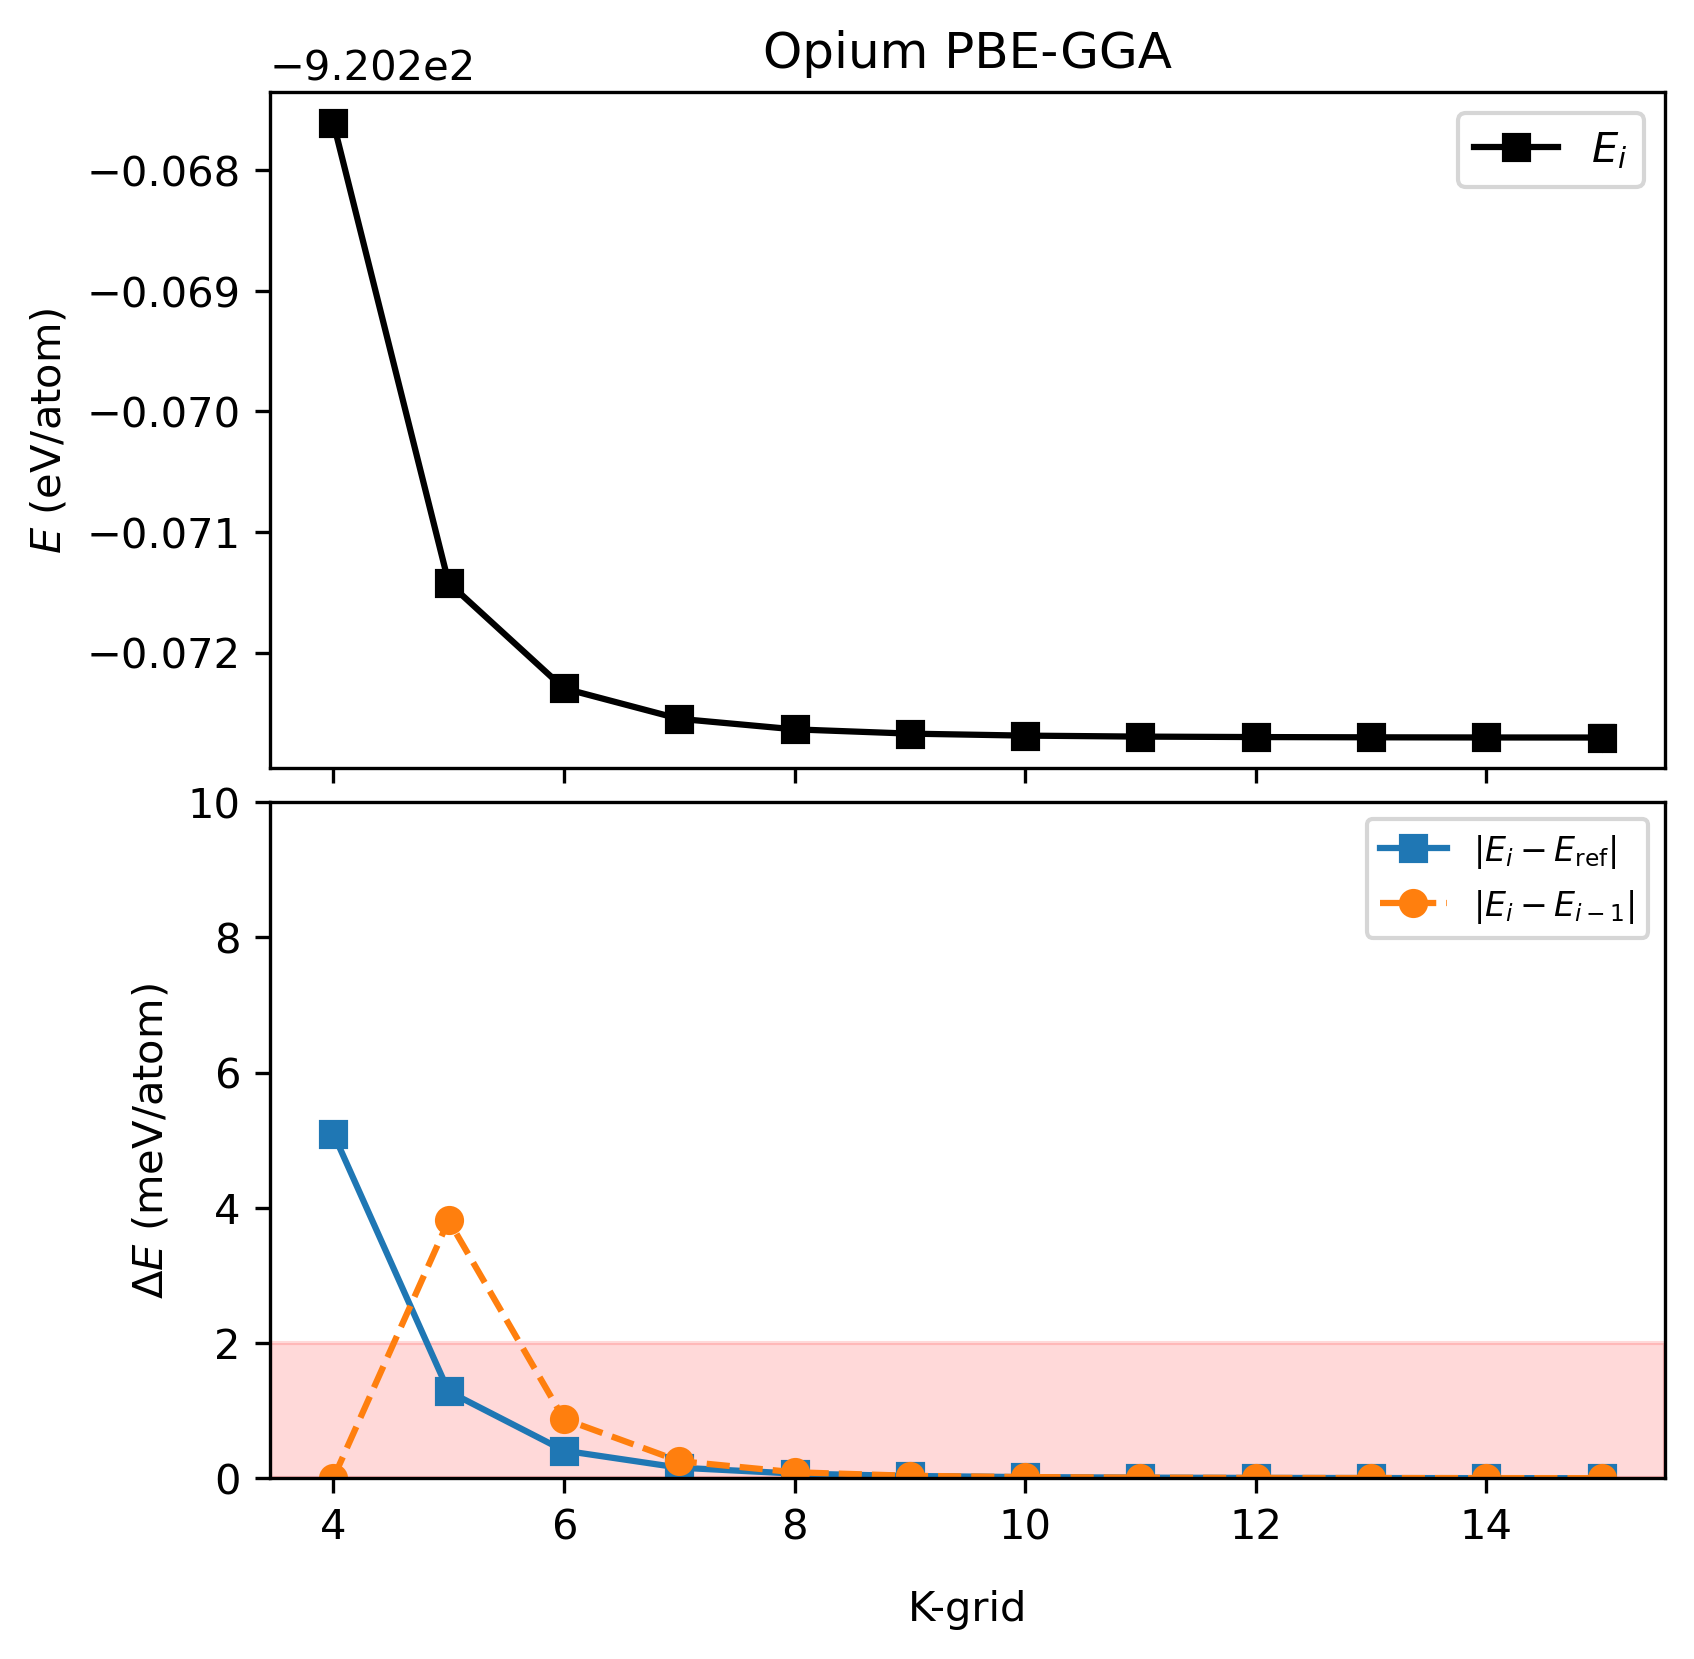

In [32]:
plot_convergence(df, pseudopot_title='Opium PBE-GGA')

In [ ]:
df.loc[:8]['E/atom'] - df.loc[:8]['E/atom'].min() 

0    0.005092
1    0.001278
2    0.000403
3    0.000151
4    0.000064
5    0.000028
6    0.000012
7    0.000004
8    0.000000
Name: E/atom, dtype: float64

In [ ]:
# files, energies = zip(*data)

In [7]:
np.arange(4,16)

array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [8]:
energies = np.array( [x[1] for x in data] )
k = np.arange(4,16)

In [9]:
dE_ref_meV = ( energies - energies.min() ) * 1_000

In [13]:
dE_ref_meV

array([5.09628403e+00, 1.28233646e+00, 4.07388431e-01, 1.55172917e-01,
       6.78924029e-02, 3.23815470e-02, 1.59186596e-02, 7.75524461e-03,
       3.91163644e-03, 1.87078285e-03, 5.44227760e-04, 0.00000000e+00])

In [17]:
energies - energies.min()

array([5.09628403e-03, 1.28233646e-03, 4.07388431e-04, 1.55172917e-04,
       6.78924029e-05, 3.23815470e-05, 1.59186596e-05, 7.75524461e-06,
       3.91163644e-06, 1.87078285e-06, 5.44227760e-07, 0.00000000e+00])

In [14]:
energies

array([-920.26760851, -920.27142245, -920.2722974 , -920.27254962,
       -920.2726369 , -920.27267241, -920.27268887, -920.27269703,
       -920.27270088, -920.27270292, -920.27270425, -920.27270479])

In [ ]:
ecut = list(range(20,160,10))
thr1, thr2 = 1.0, 2.0 # meV

E_per_atom = df8['E/atom'].to_numpy()
dE_ref_meV = df8['dE_ref_meV']
dE_consec_meV = df8['dE_consec_meV']

fig, (axE, axdE) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(6, 6),
        dpi=300,
        gridspec_kw={'hspace': 0.05}
)

 # === Painel (a): energia por átomo vs cutoff ===

axE.set_title('Kinetic energy cutoff convergence')
axE.set_ylabel(r'$E$ (eV/atom)')
axE.plot(ecut, E_per_atom, marker='s', ls='-', color='black',label=r"$E_i$")
axE.scatter(ecut[-1], E_per_atom[-1], marker='v', )
axE.legend()

# === Painel (b): diferenças em meV/átomo ===
# Usar módulo das diferenças
axdE.plot(ecut, dE_ref_meV, marker='s', ls='-', label=r'$|E_i - E_{\mathrm{ref}}|$')
axdE.plot(ecut, dE_consec_meV, marker='o', ls='--', label=r'$|E_{i} - E_{i-1}|$')

# Faixa de tolerância (0–2 meV/átomo)
axdE.axhspan(0.0, thr2, alpha=0.9,color='red')
# axdE.axhline(thr2, ls='-.', linewidth=1.0, label=r'$2\ \mathrm{meV/atom}$',color='red')
# axdE.axhline(thr1, ls=':', linewidth=1.0, label=r'$1\ \mathrm{meV/atom}$',color='red')

axdE.set_ylabel(r'$\Delta E$ (meV/atom)')
axdE.set_xlabel(r'Kinetic energy cutoff (Ry)', labelpad=10)

# Se quiser ver também a queda gigante de 20→30 Ry, pode usar semilogy:
# axdE.set_yscale('log')

axdE.legend(fontsize=8, loc='upper right')

# Limites de y focando na região relevante (ajuste se necessário)
# axdE.set_ylim(bottom=0.1, top=max(5.0, np.max(np.abs(dE_ref_meV[1:]))*1.1))


plt.show()





In [ ]:
max_k = 
E - E.min()

In [ ]:
fig  = plt.figure(dpi=300)

plt.title('Opium PBE-GGA')
k = range(4,16,1)
plt.plot(k, energies, marker='s', color='k')
plt.xlabel('k-grid')
plt.ylabel(r'$E$ (eV)')
for i, (x, y) in enumerate(zip(k, energies)):
    if i == 0:
        plt.text(x+.8, y, f'{deltaE[i]:.2e}', fontsize=8, ha='center', va='bottom', rotation=0)
    elif i == 3:
        plt.text(x+0.2, y+4e-4, f'{deltaE[i]:.2e}', fontsize=8, ha='center', va='bottom', rotation=70, color='red')
    else:
        plt.text(x+0.2, y+4e-4, f'{deltaE[i]:.2e}', fontsize=8, ha='center', va='bottom', rotation=70)
plt.tight_layout()
plt.savefig('kpoints.pdf')
plt.show()

ecutwfc = 80 Ry  
k-grid = 7x7x5